# `qufin.microstructure` Tutorial

Market **microstructure** studies how prices are *actually formed* — one
trade and one quote at a time — rather than treating price as an abstract
random walk. The questions it answers are intensely practical:

* **Who initiated this trade — the buyer or the seller?** (classification)
* **What does it cost to cross the spread right now?** (spread estimators)
* **How far does a given order push the price?** (price impact)
* **Is the order flow one-sided?** (order-flow imbalance)
* **Is the flow *toxic* — likely to be informed?** (VPIN)

These are the building blocks of execution algorithms, liquidity risk
models, and short-horizon alpha. This subpackage implements the standard
estimators on plain `numpy`/`polars` columns so they work with any feed.

**Sections**

0. Synthetic market data — trades, quotes, and an informed burst
1. Trade-sign classification — tick, quote, Lee-Ready, EMO, BVC
2. Spread estimators — quoted/effective/realized & Roll/Corwin-Schultz/Abdi-Ranaldo
3. Price impact & illiquidity — Kyle's λ, Hasbrouck's λ, Amihud
4. Order-flow imbalance — signed volume, rolling imbalance, OFI
5. VPIN — order-flow toxicity in volume time


## Why the aggressor side matters

A public trade print tells you *price* and *size* but usually **not** who
crossed the spread. Yet almost every microstructure measure needs that
sign: effective spread, order-flow imbalance, Kyle's λ and VPIN are all
defined in terms of *signed* volume.

Since the sign is unobserved, it must be **inferred**. The classic rules
trade off data requirements against accuracy:

| Rule | Needs | Idea |
|---|---|---|
| Tick rule | trades only | up-tick ⇒ buy, down-tick ⇒ sell |
| Quote rule | trades + quotes | above mid ⇒ buy, below ⇒ sell |
| Lee-Ready | trades + quotes | quote rule, tick-rule tiebreak at the mid |
| EMO | trades + quotes | quotes only *at* the bid/ask, else tick |
| BVC | bar prices + volume | assign a *fraction* of volume to buys |

Everything downstream inherits the classification error, so picking the
right rule for your data is the first decision.


In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np

from qufin.microstructure import (
    # classification
    tick_rule, quote_rule, lee_ready, emo_rule, bvc,
    # spread
    quoted_spread, effective_spread, realized_spread,
    roll_spread, corwin_schultz, abdi_ranaldo,
    # impact
    kyle_lambda, hasbrouck_lambda, amihud_illiquidity,
    # flow
    signed_volume, trade_imbalance, order_flow_imbalance,
    # informed trading
    vpin,
)

plt.rcParams.update({
    'figure.figsize': (13, 5),
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
COLOR_BUY = '#1f8e3a'
COLOR_SELL = '#c4302b'


## 0. Synthetic market data

Free vendor feeds don't give tick-by-tick trades *and* L1 quotes, so we
**simulate** a continuous-double-auction tape with a known data-generating
process. That lets us check each estimator against the *true* value it is
supposed to recover.

The model:

* An efficient (fundamental) price follows a random walk.
* The quoted bid/ask straddle the efficient price by a half-spread.
* Each trade hits the bid or lifts the ask with a probability tilted by a
  latent **order-flow imbalance** that spikes during an *informed burst*
  midway through the session — exactly the regime VPIN is built to detect.


In [2]:
def simulate_market(n=20_000, *, half_spread=0.02, sigma=0.01, seed=0):
    rng = np.random.default_rng(seed)
    # Efficient price (latent fundamental) as a random walk.
    efficient = 100.0 + np.cumsum(rng.normal(0.0, sigma, size=n))

    # Latent buy-probability: 0.5 baseline, with a one-sided informed burst.
    buy_prob = np.full(n, 0.5)
    burst = slice(n // 2, n // 2 + n // 5)
    buy_prob[burst] = 0.80
    q = np.where(rng.random(n) < buy_prob, 1.0, -1.0)  # true aggressor side

    bid = efficient - half_spread
    ask = efficient + half_spread
    # Trade prints at the bid (sell) or ask (buy) plus rare mid prints.
    price = np.where(q > 0, ask, bid)
    mid = 0.5 * (bid + ask)
    bid_size = rng.uniform(1.0, 10.0, size=n)
    ask_size = rng.uniform(1.0, 10.0, size=n)
    size = rng.lognormal(mean=1.0, sigma=0.5, size=n)
    return {
        'efficient': efficient, 'price': price, 'mid': mid,
        'bid': bid, 'ask': ask, 'bid_size': bid_size, 'ask_size': ask_size,
        'size': size, 'true_sign': q, 'half_spread': half_spread,
        'burst': burst,
    }

m = simulate_market()
price, mid, bid, ask = m['price'], m['mid'], m['bid'], m['ask']
size, true_sign = m['size'], m['true_sign']
print(f"{price.size} trades; true spread = {2 * m['half_spread']:.4f}")


20000 trades; true spread = 0.0400


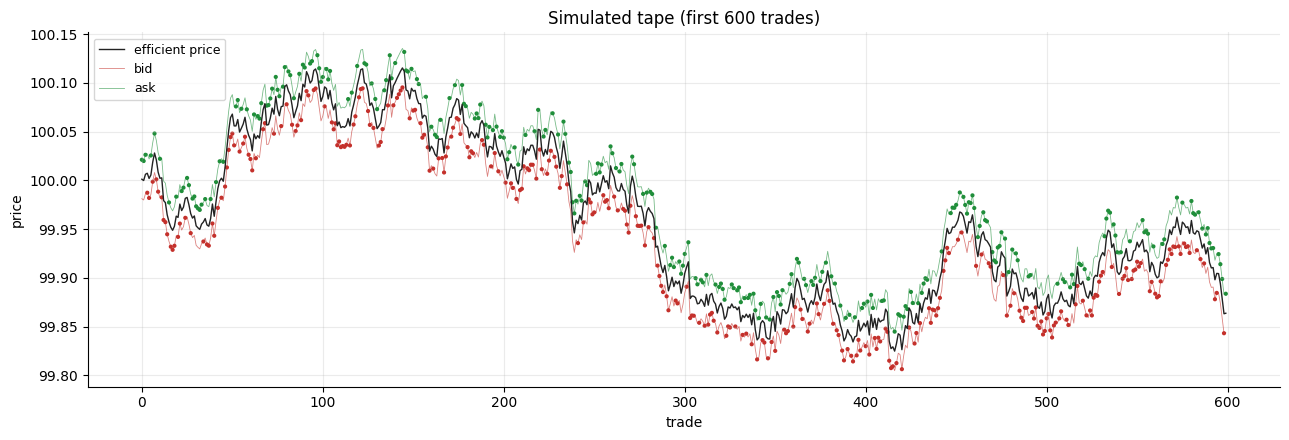

In [3]:
fig, ax = plt.subplots(figsize=(13, 4.5))
sl = slice(0, 600)
x = np.arange(price[sl].size)
ax.plot(x, m['efficient'][sl], color='#222', lw=1.0, label='efficient price')
ax.plot(x, bid[sl], color=COLOR_SELL, lw=0.6, alpha=0.6, label='bid')
ax.plot(x, ask[sl], color=COLOR_BUY, lw=0.6, alpha=0.6, label='ask')
ax.scatter(x, price[sl], s=4, c=np.where(true_sign[sl] > 0, COLOR_BUY, COLOR_SELL))
ax.set_title('Simulated tape (first 600 trades)')
ax.set_ylabel('price'); ax.set_xlabel('trade'); ax.legend(loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()


## 1. Trade-sign classification

We know the *true* sign in the simulation, so we can score each rule's
accuracy. With clean quotes the quote-based rules should be near-perfect;
the tick rule is noisier because flat/criss-cross prints break it.


In [4]:
signs = {
    'tick': tick_rule(price),
    'quote': quote_rule(price, bid, ask),
    'lee_ready': lee_ready(price, bid, ask),
    'emo': emo_rule(price, bid, ask),
}
for name, s in signs.items():
    acc = np.mean(s == true_sign)
    print(f'{name:>10}: accuracy = {acc:6.2%}')


      tick: accuracy = 72.75%
     quote: accuracy = 100.00%
 lee_ready: accuracy = 100.00%
       emo: accuracy = 100.00%


### Bulk Volume Classification (BVC)

When you only have *bars* (OHLC + volume) rather than signed trades, BVC
assigns a continuous buy *fraction* per bar from the standardised price
change, using a heavy-tailed Student-t CDF. Aggregated over our tape it
should track the latent buy-probability — including the informed burst.


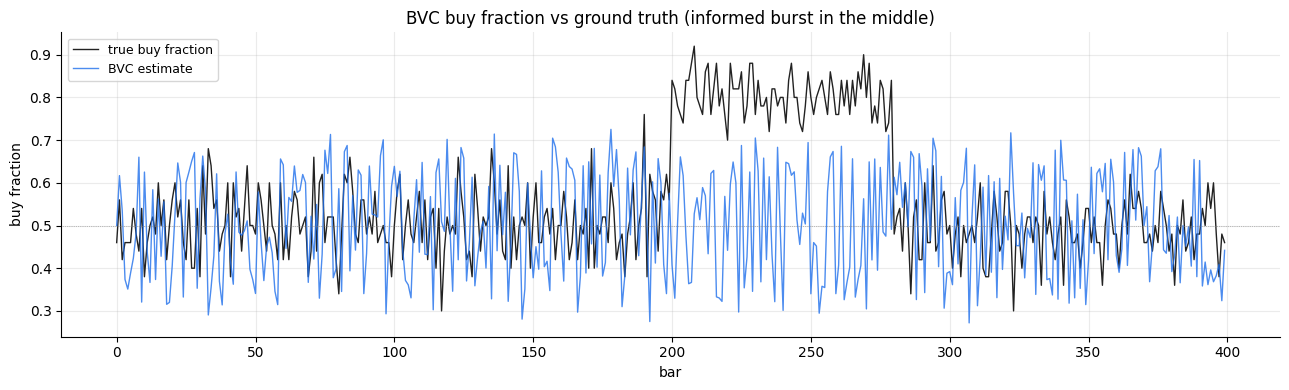

In [5]:
# Aggregate trades into fixed-count bars, then run BVC on bar closes.
bar_n = 50
n_bars = price.size // bar_n
bar_close = price[:n_bars * bar_n].reshape(n_bars, bar_n)[:, -1]
bar_buy_prob_true = true_sign[:n_bars * bar_n].reshape(n_bars, bar_n)
bar_buy_prob_true = (bar_buy_prob_true > 0).mean(axis=1)

frac = bvc(bar_close)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(bar_buy_prob_true, color='#222', lw=1.0, label='true buy fraction')
ax.plot(frac, color='#1f6feb', lw=1.0, alpha=0.8, label='BVC estimate')
ax.axhline(0.5, color='#888', lw=0.5, ls=':')
ax.set_title('BVC buy fraction vs ground truth (informed burst in the middle)')
ax.set_ylabel('buy fraction'); ax.set_xlabel('bar'); ax.legend(loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()


## 2. Spread estimators

**Quoted spread** (`ask − bid`) is the headline cost but overstates what
takers actually pay when trades occur inside the quotes. **Effective
spread** `2 q (p − m)` measures the realised cost relative to the
midpoint. **Realized spread** compares the trade to the midpoint *τ*
events later — the part of the spread that is *not* adverse selection.


In [6]:
q = lee_ready(price, bid, ask)
qs = quoted_spread(bid, ask)
es = effective_spread(price, bid, ask, signs=q)
rs = realized_spread(price, mid, signs=q, tau=20)

print(f'mean quoted spread    : {np.nanmean(qs):.4f}')
print(f'mean effective spread : {np.nanmean(es):.4f}')
print(f'mean realized spread  : {np.nanmean(rs):.4f}')
print(f'adverse-selection cost: {np.nanmean(es) - np.nanmean(rs):.4f}')


mean quoted spread    : 0.0400
mean effective spread : 0.0400
mean realized spread  : 0.0393
adverse-selection cost: 0.0007


### Spread from prices alone

When you have *no* quotes, indirect estimators recover the spread from
price statistics. **Roll (1984)** uses the negative autocovariance of
price changes that bid-ask bounce induces; **Corwin-Schultz (2012)** and
**Abdi-Ranaldo (2017)** use daily high/low/close ranges. Below, Roll is
applied to the tape and should land near the true 0.04.


In [7]:
print(f'true spread        : {2 * m["half_spread"]:.4f}')
print(f'Roll estimate      : {roll_spread(price):.4f}')

# Range-based estimators need OHLC bars; aggregate the tape into 100 bars.
nb = 100
step = price.size // nb
hi = np.array([price[i*step:(i+1)*step].max() for i in range(nb)])
lo = np.array([price[i*step:(i+1)*step].min() for i in range(nb)])
cl = np.array([price[i*step:(i+1)*step][-1] for i in range(nb)])
print(f'Corwin-Schultz mean: {np.nanmean(corwin_schultz(hi, lo)):.4f}')
print(f'Abdi-Ranaldo mean  : {np.nanmean(abdi_ranaldo(hi, lo, cl)):.4f}')


true spread        : 0.0400
Roll estimate      : 0.0385
Corwin-Schultz mean: 0.0007
Abdi-Ranaldo mean  : 0.0006


## 3. Price impact & illiquidity

**Kyle's λ** is the slope of price changes on signed order flow: the
deeper the book, the *smaller* λ. **Hasbrouck's λ** uses √volume
(concave impact). **Amihud's ILLIQ** needs only daily bars — the average
ratio of absolute return to dollar volume — and is the workhorse
low-frequency liquidity proxy.


In [8]:
dp = np.diff(price)
sv = signed_volume(q, size)[1:]
impact = kyle_lambda(dp, sv)
print(impact)
print(f"Kyle λ = {impact.lam:.3g}  (price move per unit signed volume)")

# Amihud on bar returns vs bar dollar-volume.
bar_ret = np.diff(cl) / cl[:-1]
bar_dvol = np.array([(price[i*step:(i+1)*step] * size[i*step:(i+1)*step]).sum()
                     for i in range(nb)])[1:]
print(f"Amihud ILLIQ = {amihud_illiquidity(bar_ret, bar_dvol):.4g}")


PriceImpact(λ=0.00476723, R²=0.3219, t=97.440, n=19999)
Kyle λ = 0.00477  (price move per unit signed volume)
Amihud ILLIQ = 0.02039


## 4. Order-flow imbalance

**Trade imbalance** is the rolling net of signed volume in `[-1, 1]`.
**Order-flow imbalance (OFI)** (Cont-Kukanov-Stoikov 2014) goes further,
using L1 *quote* events — size added at the bid vs the ask — and is the
single most informative top-of-book predictor of short-horizon returns.
Both should light up during the informed burst.


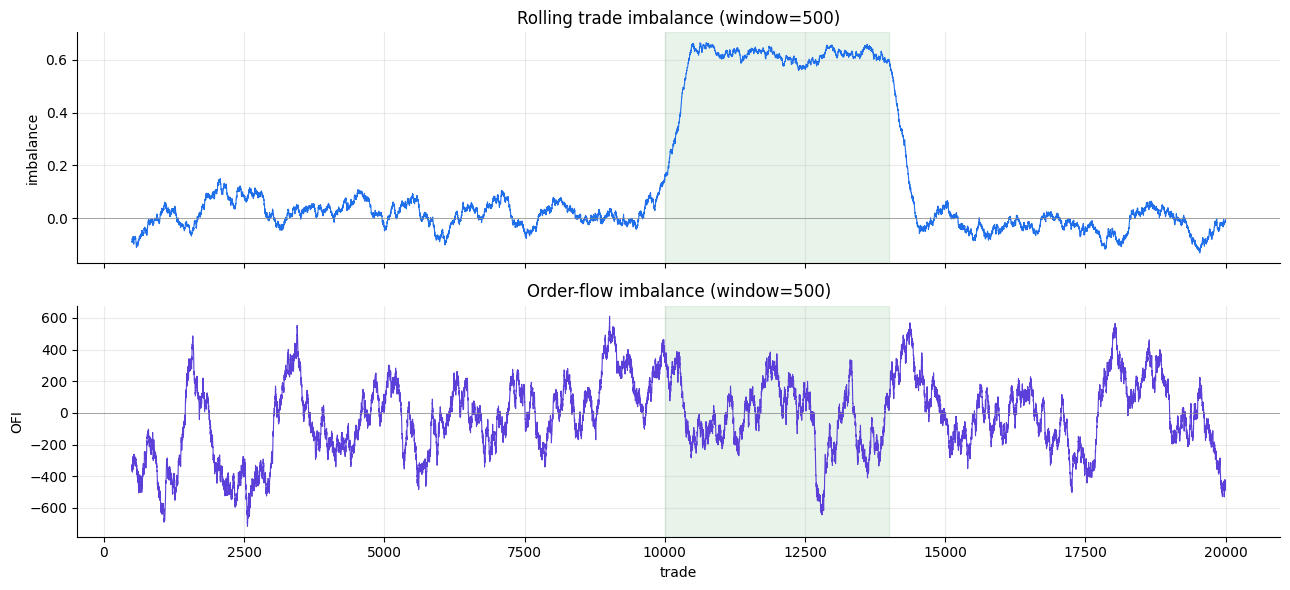

In [9]:
ti = trade_imbalance(q, size, window=500)
ofi = order_flow_imbalance(bid, ask, m['bid_size'], m['ask_size'], window=500)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(13, 6))
ax1.plot(ti, color='#1f6feb', lw=0.8)
ax1.axhline(0, color='#888', lw=0.5)
ax1.axvspan(m['burst'].start, m['burst'].stop, color=COLOR_BUY, alpha=0.1)
ax1.set_title('Rolling trade imbalance (window=500)'); ax1.set_ylabel('imbalance')
ax2.plot(ofi, color='#5b3fd8', lw=0.8)
ax2.axhline(0, color='#888', lw=0.5)
ax2.axvspan(m['burst'].start, m['burst'].stop, color=COLOR_BUY, alpha=0.1)
ax2.set_title('Order-flow imbalance (window=500)'); ax2.set_ylabel('OFI'); ax2.set_xlabel('trade')
plt.tight_layout(); plt.show()


## 5. VPIN — order-flow toxicity

VPIN (Easley, López de Prado & O'Hara 2012) measures the share of
*informed* flow in **volume time**: classify volume with BVC, pack it into
equal-volume buckets, and average the absolute order imbalance over a
rolling window of buckets. It famously rose ahead of the 2010 Flash Crash.

Our informed burst should produce a clear VPIN spike.


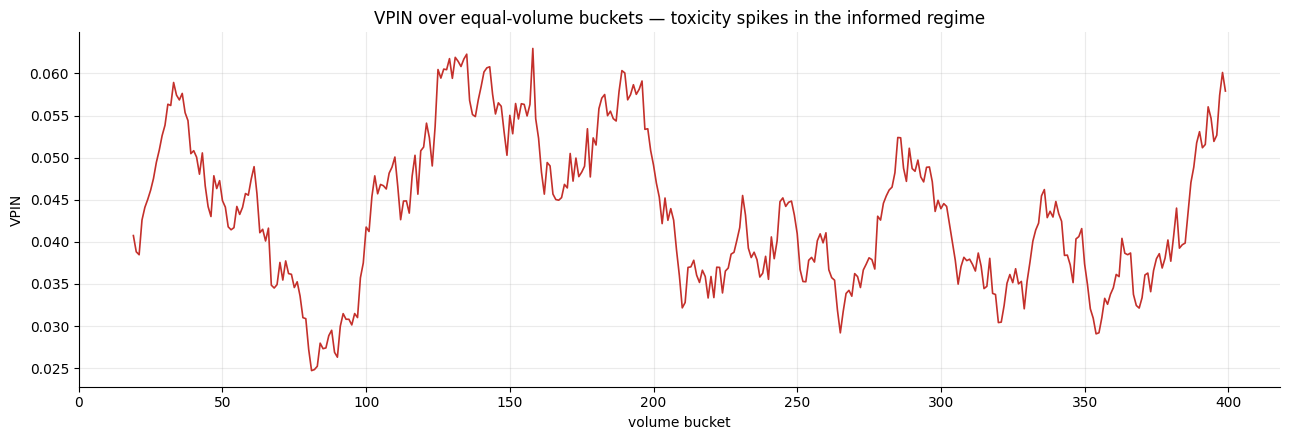

shape: (9, 6)
┌────────────┬────────────┬────────────┬─────────────┬─────────────────┬──────────┐
│ statistic  ┆ bucket     ┆ buy_volume ┆ sell_volume ┆ order_imbalance ┆ vpin     │
│ ---        ┆ ---        ┆ ---        ┆ ---         ┆ ---             ┆ ---      │
│ str        ┆ f64        ┆ f64        ┆ f64         ┆ f64             ┆ f64      │
╞════════════╪════════════╪════════════╪═════════════╪═════════════════╪══════════╡
│ count      ┆ 400.0      ┆ 400.0      ┆ 400.0       ┆ 400.0           ┆ 400.0    │
│ null_count ┆ 0.0        ┆ 0.0        ┆ 0.0         ┆ 0.0             ┆ 0.0      │
│ mean       ┆ 199.5      ┆ 76.85685   ┆ 76.693092   ┆ 0.043912        ┆ NaN      │
│ std        ┆ 115.614301 ┆ 4.266166   ┆ 4.266166    ┆ 0.033997        ┆ NaN      │
│ min        ┆ 0.0        ┆ 65.880576  ┆ 62.922153   ┆ 0.000185        ┆ 0.024717 │
│ 25%        ┆ 100.0      ┆ 74.139279  ┆ 73.87141    ┆ 0.018233        ┆ 0.036896 │
│ 50%        ┆ 200.0      ┆ 76.789199  ┆ 76.790359   ┆ 0.03688

In [10]:
res = vpin(price, size, n_buckets=400, window=20)
df = res.to_dataframe()

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(df['bucket'], df['vpin'], color='#c4302b', lw=1.2)
ax.set_title('VPIN over equal-volume buckets — toxicity spikes in the informed regime')
ax.set_ylabel('VPIN'); ax.set_xlabel('volume bucket')
plt.tight_layout(); plt.show()
print(res.to_dataframe().describe())


## 6. PIN — the structural cousin of VPIN

VPIN is a model-free toxicity proxy in volume time. **PIN** (Easley, Kiefer,
O'Hara & Paperman 1996) is the fully *parametric* daily model behind the same
idea: estimate, by maximum likelihood from daily buy/sell counts, the
probability of an information event (`α`), the informed arrival rate (`μ`) and
the uninformed rates (`εb`, `εs`), then

    PIN = α μ / (α μ + εb + εs).

We aggregate the simulated tape into "days" and fit it — the informed burst
should push the estimate well above zero.


PIN=0.3050 (α=1.000, δ=0.800, μ=24.40, εb=40.03, εs=15.57)
PIN = 0.305  (log-likelihood -1624, converged=True)


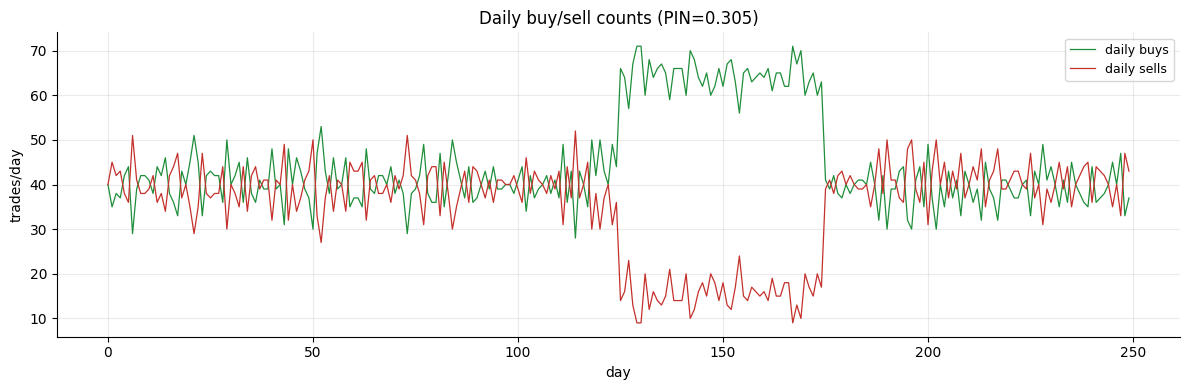

In [11]:
from qufin.microstructure import pin

q_all = lee_ready(price, bid, ask)
n_days = 250
per = price.size // n_days
buys = np.array([(q_all[d*per:(d+1)*per] > 0).sum() for d in range(n_days)], dtype=float)
sells = np.array([(q_all[d*per:(d+1)*per] < 0).sum() for d in range(n_days)], dtype=float)

res = pin(buys, sells)
print(res)
print(f'PIN = {res.pin:.3f}  (log-likelihood {res.log_lik:.0f}, converged={res.converged})')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(buys, color=COLOR_BUY, lw=0.9, label='daily buys')
ax.plot(sells, color=COLOR_SELL, lw=0.9, label='daily sells')
ax.set_title(f'Daily buy/sell counts (PIN={res.pin:.3f})')
ax.set_ylabel('trades/day'); ax.set_xlabel('day'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


## What next?

* **Plug into execution.** Effective/realized spread and Kyle's λ are the
  raw inputs to transaction-cost models and optimal-execution schedules.
* **Use VPIN / OFI as features.** Both are predictive of short-horizon
  volatility and returns — natural features for the
  `qufin.trading.training` ML pipeline.
* **Combine with information-driven bars.** `qufin.data.bars` builds
  imbalance/run bars from the same tick feed; pair them with these
  liquidity measures for a fuller microstructure picture.
* **Validate on real ticks.** Swap `simulate_market` for an IBKR / vendor
  tick+quote feed (`qufin.data.TICK_SCHEMA`) — the rest runs unchanged.
